In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import train_test_split, cross_val_score

In [107]:
def clean_fred_data(file_path, value_col_name):
    df = pd.read_csv(file_path)
    # Automatically find the date column
    date_col = [c for c in df.columns if 'date' in c.lower()][0]
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col)
    # Convert all columns to numeric
    df_numeric = df.apply(pd.to_numeric, errors='coerce')
    # Resample to quarterly
    df_q = df_numeric.resample('QE').mean()
    df_q.columns = [value_col_name]
    return df_q

In [108]:
# historical data
df_loans = clean_fred_data('BUSLOANS.csv', 'Loans_Billions')
df_cpi = clean_fred_data('CPI.csv', 'CPI')
df_unemp = clean_fred_data('UNEMPLOYMENT.csv', 'Unemployment_Rate')
df_charge = clean_fred_data('CORBLACBS.csv', 'Chargeoff_Rate')  # Added charge-off data
df_gdp = clean_fred_data('GDPC1.csv', 'GDP')

df_history = pd.concat([df_loans, df_cpi, df_unemp, df_charge, df_gdp], axis=1).dropna()


In [109]:
#check stationarity
df_history['Loan_Growth'] = df_history['Loans_Billions'].pct_change(4) * 100
df_history['Inflation'] = df_history['CPI'].pct_change(4) * 100
df_history = df_history.dropna()

print(df_history.head())

                  Loans_Billions         CPI  Unemployment_Rate  \
observation_date                                                  
1986-03-31            502.374267  109.566667           7.033333   
1986-06-30            508.855633  109.033333           7.166667   
1986-09-30            515.118767  109.700000           6.966667   
1986-12-31            526.926900  110.466667           6.833333   
1987-03-31            548.151267  111.800000           6.600000   

                  Chargeoff_Rate       GDP  Loan_Growth  Inflation  
observation_date                                                    
1986-03-31                  1.46  8749.127     5.441802   3.105395  
1986-06-30                  1.47  8788.524     5.876495   1.678583  
1986-09-30                  1.56  8872.601     5.060920   1.668211  
1986-12-31                  1.48  8920.193     6.140820   1.345566  
1987-03-31                  1.27  8986.367     9.112131   2.038333  


In [110]:
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

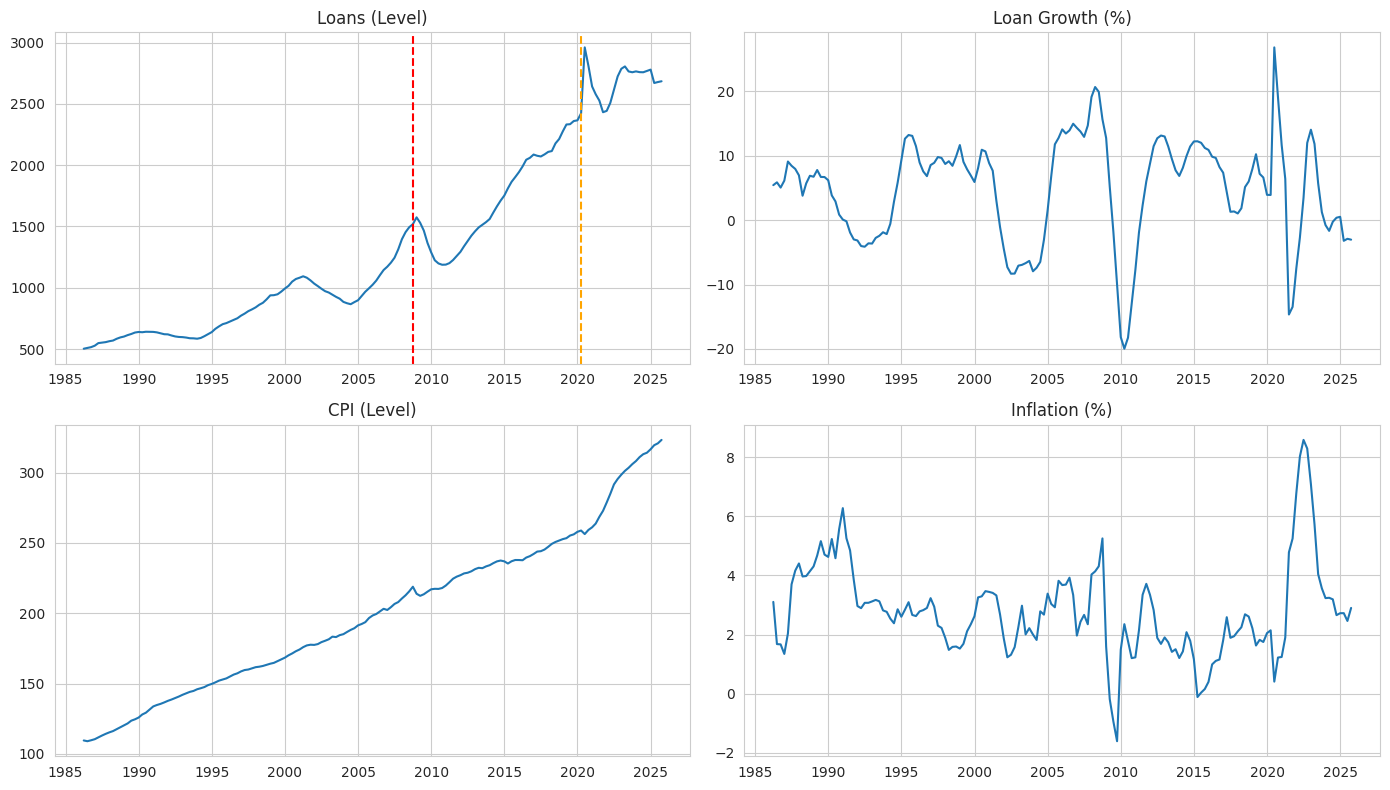

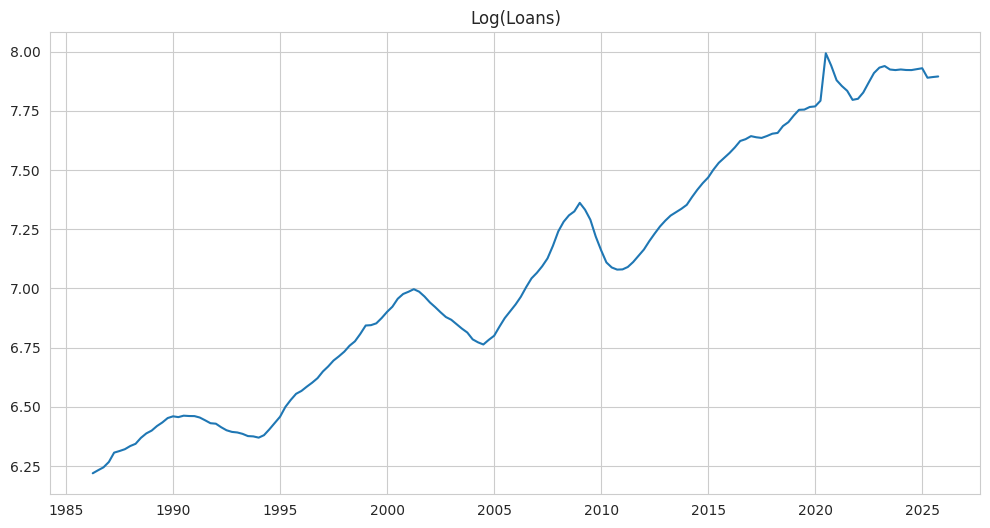

In [111]:
df = df_history.copy()

# -----------------------------
# 1️⃣ Plot the Data First
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(14,8))

# Loans
axes[0,0].plot(df.index, df['Loans_Billions'])
axes[0,0].set_title('Loans (Level)')
axes[0,0].axvline(pd.to_datetime('2008-09-30'), color='red', linestyle='--')  # 2008 Crisis
axes[0,0].axvline(pd.to_datetime('2020-03-31'), color='orange', linestyle='--') # COVID

# Loan growth
axes[0,1].plot(df.index, df['Loan_Growth'])
axes[0,1].set_title('Loan Growth (%)')

# CPI & Inflation
axes[1,0].plot(df.index, df['CPI'])
axes[1,0].set_title('CPI (Level)')

axes[1,1].plot(df.index, df['Inflation'])
axes[1,1].set_title('Inflation (%)')

plt.tight_layout()
plt.show()

# Optional: log-transform check
df['Loans_log'] = np.log(df['Loans_Billions'])
plt.plot(df.index, df['Loans_log'])
plt.title('Log(Loans)')
plt.show()

In [112]:
import numpy as np
from statsmodels.tsa.stattools import adfuller

# Optional: log-transform Loans
df_history['Log_Loans'] = np.log(df_history['Loans_Billions'])

# Columns to test
cols_to_test = ['Log_Loans', 'Loan_Growth', 'Inflation', 'Chargeoff_Rate', 'Unemployment_Rate', 'GDP']

# Function to run ADF test
def adf_summary(series, name):
    result = adfuller(series.dropna())
    print(f"ADF Test for {name}:")
    print(f"  Test Statistic = {result[0]:.4f}")
    print(f"  p-value = {result[1]:.4f}")
    print(f"  # Lags Used = {result[2]}")
    print(f"  # Observations = {result[3]}")
    print(f"  Critical Values:")
    for k, v in result[4].items():
        print(f"    {k}: {v:.4f}")
    print("-"*40)

# Run tests
for col in cols_to_test:
    adf_summary(df_history[col], col)

ADF Test for Log_Loans:
  Test Statistic = -0.6026
  p-value = 0.8704
  # Lags Used = 1
  # Observations = 157
  Critical Values:
    1%: -3.4727
    5%: -2.8801
    10%: -2.5767
----------------------------------------
ADF Test for Loan_Growth:
  Test Statistic = -4.2975
  p-value = 0.0004
  # Lags Used = 14
  # Observations = 144
  Critical Values:
    1%: -3.4766
    5%: -2.8818
    10%: -2.5776
----------------------------------------
ADF Test for Inflation:
  Test Statistic = -2.1350
  p-value = 0.2307
  # Lags Used = 12
  # Observations = 146
  Critical Values:
    1%: -3.4760
    5%: -2.8815
    10%: -2.5774
----------------------------------------
ADF Test for Chargeoff_Rate:
  Test Statistic = -3.6837
  p-value = 0.0043
  # Lags Used = 3
  # Observations = 155
  Critical Values:
    1%: -3.4733
    5%: -2.8804
    10%: -2.5768
----------------------------------------
ADF Test for Unemployment_Rate:
  Test Statistic = -3.3587
  p-value = 0.0125
  # Lags Used = 0
  # Observation

In [113]:
# Check exact column names
print(df_history.columns.tolist())

['Loans_Billions', 'CPI', 'Unemployment_Rate', 'Chargeoff_Rate', 'GDP', 'Loan_Growth', 'Inflation', 'Log_Loans']


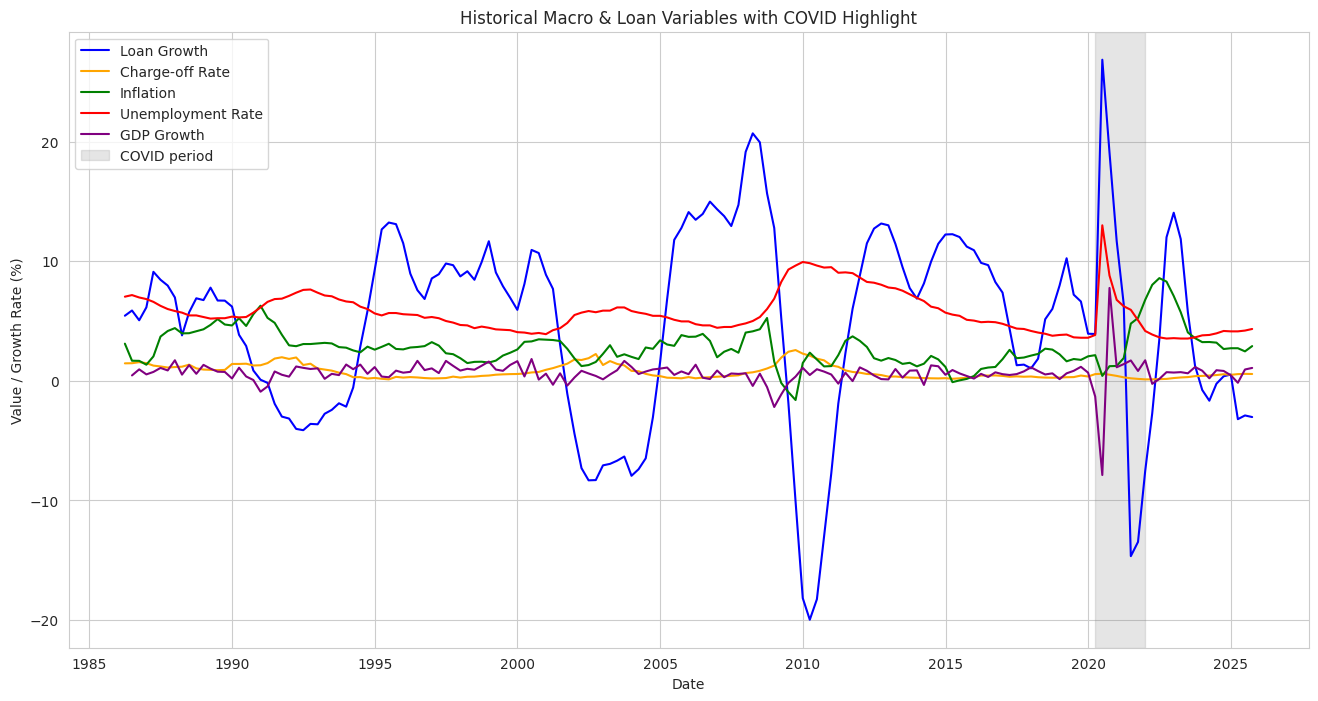

In [114]:
import matplotlib.pyplot as plt

# Make sure 'observation_date' is the index
df_plot = df_history.copy()
df_plot.index = pd.to_datetime(df_plot.index)

# Compute GDP growth rate (quarter-over-quarter, in %)
df_plot['GDP_Growth'] = df_plot['GDP'].pct_change() * 100

# Set up figure
plt.figure(figsize=(16, 8))

# Plot Loan Growth
plt.plot(df_plot.index, df_plot['Loan_Growth'], label='Loan Growth', color='blue')

# Plot Charge-off Rate
plt.plot(df_plot.index, df_plot['Chargeoff_Rate'], label='Charge-off Rate', color='orange')

# Plot Inflation
plt.plot(df_plot.index, df_plot['Inflation'], label='Inflation', color='green')

# Plot Unemployment Rate
plt.plot(df_plot.index, df_plot['Unemployment_Rate'], label='Unemployment Rate', color='red')

# Plot GDP Growth
plt.plot(df_plot.index, df_plot['GDP_Growth'], label='GDP Growth', color='purple')

# Highlight potential COVID period (2020 Q1 to 2021 Q4)
plt.axvspan(pd.to_datetime('2020-03-31'), pd.to_datetime('2021-12-31'), color='gray', alpha=0.2, label='COVID period')

# Labels & legend
plt.title('Historical Macro & Loan Variables with COVID Highlight')
plt.xlabel('Date')
plt.ylabel('Value / Growth Rate (%)')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

In [115]:
# Define COVID period (quarterly)
covid_start = '2020-03-31'
covid_end = '2021-12-31'

# Make sure 'GDP' is transformed into growth rate first
df_history['GDP_Growth'] = df_history['GDP'].pct_change(4) * 100  # 4 quarters

# Create COVID dummy: 1 during COVID, 0 otherwise
df_history['COVID_Dummy'] = 0
df_history.loc[(df_history.index >= covid_start) & (df_history.index <= covid_end), 'COVID_Dummy'] = 1

# Quick check
df_history[['Loan_Growth', 'Chargeoff_Rate', 'Inflation', 'Unemployment_Rate', 'GDP_Growth', 'COVID_Dummy']].tail(30)

,Loan_Growth,Chargeoff_Rate,Inflation,Unemployment_Rate,GDP_Growth,COVID_Dummy
observation_date,,,,,,
2018-06-30,5.147024,0.27,2.686793,3.933333,3.298963,0
2018-09-30,6.010640,0.26,2.608917,3.766667,3.130031,0
2018-12-31,7.964550,0.27,2.213519,3.833333,2.125111,0
2019-03-31,10.246243,0.30,1.630023,3.866667,1.933559,0
2019-06-30,7.201631,0.31,1.822384,3.633333,2.242126,0
2019-09-30,6.630321,0.44,1.749400,3.600000,2.797217,0
2019-12-31,3.934623,0.36,2.048585,3.600000,3.351777,0
2020-03-31,3.914939,0.56,2.143768,3.833333,1.358535,1
2020-06-30,26.843669,0.59,0.409276,13.000000,-7.398615,1


In [116]:
import statsmodels.api as sm

# -------------------------------------------------
# Step 1: Prepare lagged variables
# -------------------------------------------------
df_reg = df_history.copy()

# Lag macro variables by 1 quarter
df_reg['Loan_Growth_Lag1'] = df_reg['Loan_Growth'].shift(1)
df_reg['Chargeoff_Lag1'] = df_reg['Chargeoff_Rate'].shift(1)
df_reg['Inflation_Lag1'] = df_reg['Inflation'].shift(1)
df_reg['Unemployment_Lag1'] = df_reg['Unemployment_Rate'].shift(1)
df_reg['GDP_Lag1'] = df_reg['GDP_Growth'].shift(1)

# Drop missing rows due to lagging
df_reg = df_reg.dropna()

# -------------------------------------------------
# Step 2: Define dependent and independent variables
# -------------------------------------------------

# Loan Growth OLS
y_loan = df_reg['Loan_Growth']
X_loan = df_reg[['GDP_Growth', 'Unemployment_Rate', 'Inflation', 'COVID_Dummy',
                 'Loan_Growth_Lag1', 'Chargeoff_Lag1']]  # add lags to see predictive power
X_loan = sm.add_constant(X_loan)

# Charge-off Rate OLS
y_charge = df_reg['Chargeoff_Rate']
X_charge = df_reg[['GDP_Growth', 'Unemployment_Rate', 'Inflation', 'COVID_Dummy',
                   'Loan_Growth_Lag1', 'Chargeoff_Lag1']]  # same set of predictors
X_charge = sm.add_constant(X_charge)

# -------------------------------------------------
# Step 3: Fit the models
# -------------------------------------------------
model_loan = sm.OLS(y_loan, X_loan).fit()
model_charge = sm.OLS(y_charge, X_charge).fit()

# -------------------------------------------------
# Step 4: Review summaries
# -------------------------------------------------
print("------ Loan Growth Regression ------")
print(model_loan.summary())
print("\n------ Charge-Off Rate Regression ------")
print(model_charge.summary())

------ Loan Growth Regression ------
                            OLS Regression Results                            
Dep. Variable:            Loan_Growth   R-squared:                       0.870
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     164.6
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           1.25e-62
Time:                        15:37:21   Log-Likelihood:                -384.58
No. Observations:                 154   AIC:                             783.2
Df Residuals:                     147   BIC:                             804.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
c

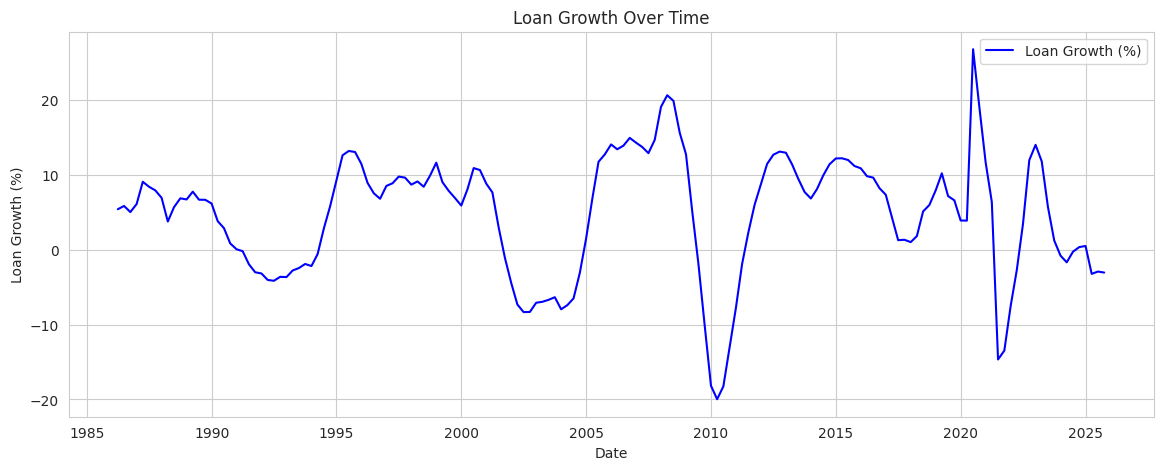

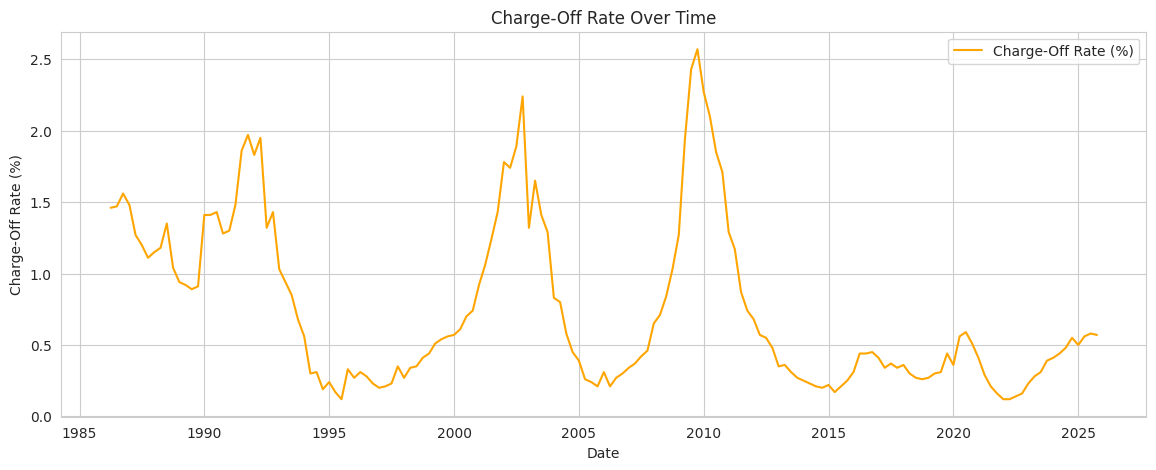

In [117]:
import matplotlib.pyplot as plt

# Ensure datetime index
df_plot = df_history.copy()
df_plot.index = pd.to_datetime(df_plot.index)

# -----------------------------
# Loan Growth Over Time
# -----------------------------
plt.figure(figsize=(14,5))
plt.plot(df_plot.index, df_plot['Loan_Growth'], color='blue', label='Loan Growth (%)')
plt.xlabel('Date')
plt.ylabel('Loan Growth (%)')
plt.title('Loan Growth Over Time')
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# Charge-Off Rate Over Time
# -----------------------------
plt.figure(figsize=(14,5))
plt.plot(df_plot.index, df_plot['Chargeoff_Rate'], color='orange', label='Charge-Off Rate (%)')
plt.xlabel('Date')
plt.ylabel('Charge-Off Rate (%)')
plt.title('Charge-Off Rate Over Time')
plt.grid(True)
plt.legend()
plt.show()

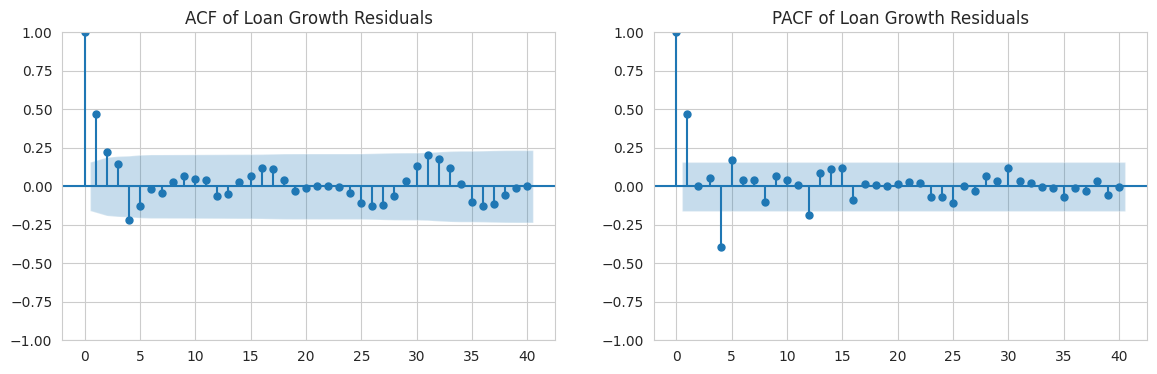

In [118]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Example for Loan Growth residuals
resid_loan = model_loan.resid  # residuals from your OLS

# Plot ACF
fig, ax = plt.subplots(1,2, figsize=(14,4))
sm.graphics.tsa.plot_acf(resid_loan, lags=40, ax=ax[0])
ax[0].set_title('ACF of Loan Growth Residuals')

# Plot PACF
sm.graphics.tsa.plot_pacf(resid_loan, lags=40, ax=ax[1])
ax[1].set_title('PACF of Loan Growth Residuals')

plt.show()

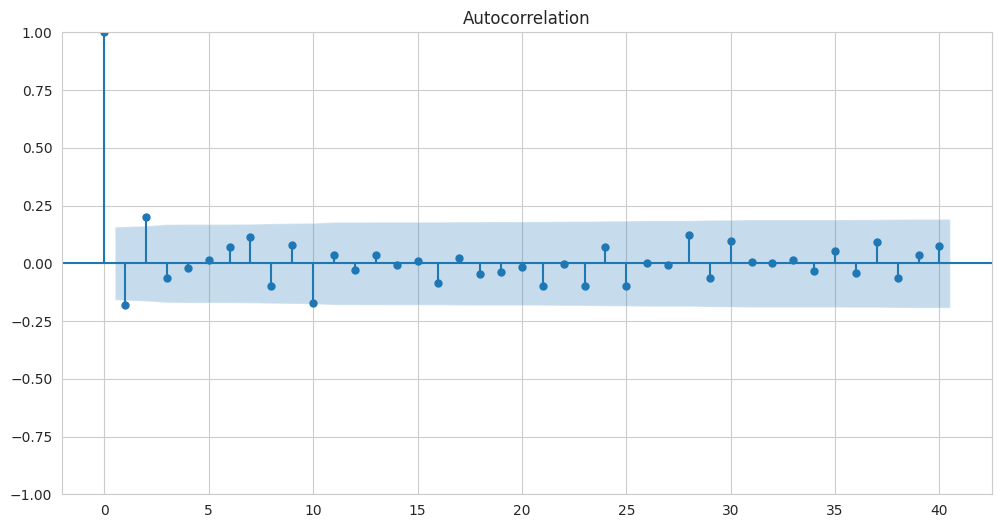

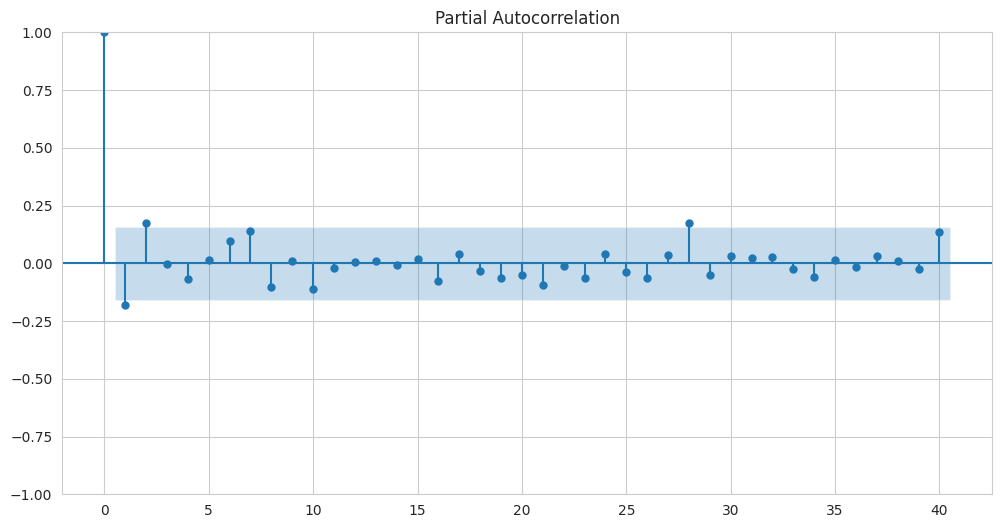

In [119]:
resid_charge = model_charge.resid
sm.graphics.tsa.plot_acf(resid_charge, lags=40)
sm.graphics.tsa.plot_pacf(resid_charge, lags=40)
plt.show()

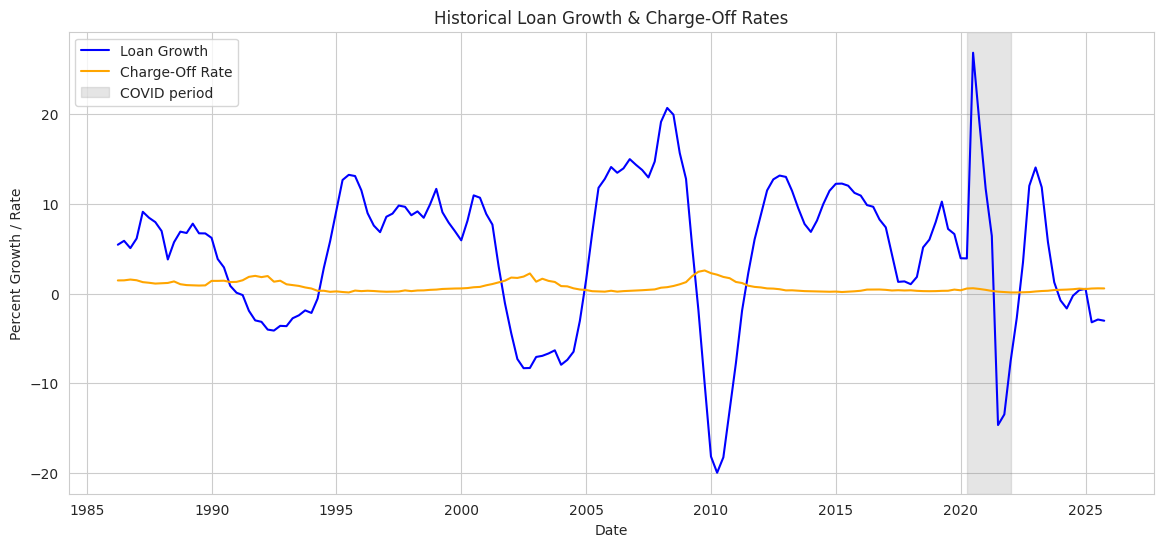

In [120]:
import matplotlib.pyplot as plt

# Historical data
plt.figure(figsize=(14,6))
plt.plot(df_history.index, df_history['Loan_Growth'], label='Loan Growth', color='blue')
plt.plot(df_history.index, df_history['Chargeoff_Rate'], label='Charge-Off Rate', color='orange')

# Highlight COVID period
plt.axvspan(pd.to_datetime('2020-03-31'), pd.to_datetime('2021-12-31'), color='gray', alpha=0.2, label='COVID period')

plt.title("Historical Loan Growth & Charge-Off Rates")
plt.xlabel("Date")
plt.ylabel("Percent Growth / Rate")
plt.legend()
plt.grid(True)
plt.show()

In [121]:
import pandas as pd

# Load NGFS Excel sheet
ngfs_file = "Downscaled_GCAM 6.0 NGFS_data.xlsx"
sheet_name = "data"  # adjust if your sheet is named differently

# Read the sheet
ngfs_df = pd.read_excel(ngfs_file, sheet_name=sheet_name)

# Show the first few rows
print(ngfs_df.head())

# List all columns
print("\nColumns in NGFS sheet:")
print(ngfs_df.columns.tolist())

                        Model            Scenario Region  \
0  Downscaling[GCAM 6.0 NGFS]  Delayed transition    AGO   
1  Downscaling[GCAM 6.0 NGFS]  Delayed transition    AGO   
2  Downscaling[GCAM 6.0 NGFS]  Delayed transition    AGO   
3  Downscaling[GCAM 6.0 NGFS]  Delayed transition    AGO   
4  Downscaling[GCAM 6.0 NGFS]  Delayed transition    AGO   

                                        Variable       Unit      2020  2021  \
0                       Carbon Sequestration|CCS  Mt CO2/yr    0.0000   NaN   
1               Carbon Sequestration|CCS|Biomass  Mt CO2/yr    0.0000   NaN   
2                Carbon Sequestration|CCS|Fossil  Mt CO2/yr    0.0000   NaN   
3  Carbon Sequestration|CCS|Industrial Processes  Mt CO2/yr    0.0000   NaN   
4                                  Emissions|CO2  Mt CO2/yr  148.1421   NaN   

   2022  2023  2024  ...  2091  2092  2093  2094  2095  2096  2097  2098  \
0   NaN   NaN   NaN  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
1   NaN   Na

In [122]:
import pandas as pd
import numpy as np

# -----------------------------
# 1️⃣ Clean FRED / historical data
# -----------------------------
def clean_fred_data(file_path, value_col_name):
    df = pd.read_csv(file_path)
    date_col = [c for c in df.columns if 'date' in c.lower()][0]
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col)
    df_numeric = df.apply(pd.to_numeric, errors='coerce')
    df_q = df_numeric.resample('QE').mean()  # quarterly
    df_q.columns = [value_col_name]
    return df_q

# Load historical data
df_loans = clean_fred_data('BUSLOANS.csv', 'Loans_Billions')
df_cpi = clean_fred_data('CPI.csv', 'CPI')
df_unemp = clean_fred_data('UNEMPLOYMENT.csv', 'Unemployment_Rate')
df_charge = clean_fred_data('CORBLACBS.csv', 'Chargeoff_Rate')
df_gdp = clean_fred_data('GDPC1.csv', 'GDP')  # your GDP CSV

# Combine into one master historical DataFrame
df_history = pd.concat([df_loans, df_cpi, df_unemp, df_charge, df_gdp], axis=1).dropna()

# -----------------------------
# 2️⃣ Feature engineering
# -----------------------------
# Quarterly growth / differences
df_history['Loan_Growth'] = df_history['Loans_Billions'].pct_change(4) * 100
df_history['Inflation'] = df_history['CPI'].pct_change(4) * 100
df_history['GDP_Growth'] = df_history['GDP'].pct_change(4) * 100

# Lagged variables for regression / ARIMAX later
df_history['Loan_Growth_Lag1'] = df_history['Loan_Growth'].shift(1)
df_history['Chargeoff_Lag1'] = df_history['Chargeoff_Rate'].shift(1)

# -----------------------------
# 3️⃣ Create COVID dummy
# -----------------------------
covid_start = '2020-03-31'
covid_end = '2021-12-31'
df_history['COVID_Dummy'] = 0
df_history.loc[(df_history.index >= covid_start) & (df_history.index <= covid_end), 'COVID_Dummy'] = 1

# Drop NA rows after creating growth rates and lags
df_history = df_history.dropna()

# -----------------------------
# ✅ Quick check
# -----------------------------
print(df_history.head())
print("\nColumns:", df_history.columns.tolist())

                  Loans_Billions         CPI  Unemployment_Rate  \
observation_date                                                  
1986-06-30            508.855633  109.033333           7.166667   
1986-09-30            515.118767  109.700000           6.966667   
1986-12-31            526.926900  110.466667           6.833333   
1987-03-31            548.151267  111.800000           6.600000   
1987-06-30            551.837367  113.066667           6.266667   

                  Chargeoff_Rate       GDP  Loan_Growth  Inflation  \
observation_date                                                     
1986-06-30                  1.47  8788.524     5.876495   1.678583   
1986-09-30                  1.56  8872.601     5.060920   1.668211   
1986-12-31                  1.48  8920.193     6.140820   1.345566   
1987-03-31                  1.27  8986.367     9.112131   2.038333   
1987-06-30                  1.20  9083.256     8.446744   3.699175   

                  GDP_Growth  Loan_Grow

In [123]:
import pandas as pd

# -----------------------------
# 1️⃣ Load NGFS NiGEM Excel
# -----------------------------
ngfs_file = "NiGEM_data.xlsx"
ngfs = pd.read_excel(ngfs_file)

# -----------------------------
# 2️⃣ Filter for US & relevant variables
# -----------------------------
ngfs_us = ngfs[ngfs['Region'] == 'NiGEM NGFS v1.24.2|United States']
ngfs_us = ngfs_us[ngfs_us['Variable'].str.contains('combined', case=False, na=False)]

# -----------------------------
# 3️⃣ Melt annual columns into long format
# -----------------------------
year_cols = [c for c in ngfs_us.columns if c.isdigit()]
ngfs_long = ngfs_us.melt(id_vars=['Model','Scenario','Region','Variable','Unit'], 
                         value_vars=year_cols,
                         var_name='Year', value_name='Value')

# Convert Year to datetime
ngfs_long['Year'] = pd.to_datetime(ngfs_long['Year'].astype(str) + '-12-31')

# -----------------------------
# 4️⃣ Pivot: Scenario + Variable as columns
# -----------------------------
ngfs_pivot = ngfs_long.pivot_table(index='Year', 
                                   columns=['Scenario','Variable'], 
                                   values='Value')

# Optional: flatten column MultiIndex
ngfs_pivot.columns = [f"{sc}_{var}" for sc, var in ngfs_pivot.columns]

# -----------------------------
# 5️⃣ Interpolate to quarterly
# -----------------------------
ngfs_quarterly = ngfs_pivot.resample('QE').interpolate(method='linear')

# Quick check
print(ngfs_quarterly.head(10))
print("\nColumns:", ngfs_quarterly.columns.tolist())

            Below 2°C_Carbon pricing ; $ per Tn CO2(combined)  \
Year                                                            
2022-12-31                                           0.000000   
2023-03-31                                           1.908148   
2023-06-30                                           3.816295   
2023-09-30                                           5.724443   
2023-12-31                                           7.632591   
2024-03-31                                           8.359504   
2024-06-30                                           9.086418   
2024-09-30                                           9.813331   
2024-12-31                                          10.540245   
2025-03-31                                          11.267158   

            Below 2°C_Central bank Intervention rate (policy interest rate) ; %(combined)  \
Year                                                                                        
2022-12-31                       

In [124]:
print(ngfs_quarterly.columns)

Index(['Below 2°C_Carbon pricing ; $ per Tn CO2(combined)',
       'Below 2°C_Central bank Intervention rate (policy interest rate) ; %(combined)',
       'Below 2°C_Coal price ; US$ per barrel (equiv)(combined)',
       'Below 2°C_Consumption (private)(combined)',
       'Below 2°C_Domestic demand(combined)',
       'Below 2°C_Effective exchange rate(combined)',
       'Below 2°C_Energy consumption (total) ; MnToe(combined)',
       'Below 2°C_Equity prices(combined)',
       'Below 2°C_Exports (goods and services)(combined)',
       'Below 2°C_Gas price ; US$ per barrel (equiv)(combined)',
       ...
       'Net Zero 2050_Productivity (output per hour worked); US$ Bn(combined)',
       'Net Zero 2050_Quarterly consumption of coal ; MnToe(combined)',
       'Net Zero 2050_Quarterly consumption of gas ; MnToe(combined)',
       'Net Zero 2050_Quarterly consumption of non-carbon ; MnToe(combined)',
       'Net Zero 2050_Quarterly consumption of oil ; MnToe(combined)',
       'Net Zero 2

Loading Historical Data...
✅ Historical Data Loaded. Rows: 309
                  Loan_Growth  Unemployment_Rate
observation_date                                
1949-03-31           1.501015           4.666667
1949-06-30          -5.088215           5.866667
1949-09-30          -8.842232           6.700000
1949-12-31          -9.727312           6.966667
1950-03-31          -6.943901           6.400000

Training ARIMAX Model...
                               SARIMAX Results                                
Dep. Variable:            Loan_Growth   No. Observations:                  309
Model:                 ARIMA(2, 0, 1)   Log Likelihood                -724.066
Date:                Mon, 02 Mar 2026   AIC                           1460.133
Time:                        15:38:55   BIC                           1482.533
Sample:                    03-31-1949   HQIC                          1469.088
                         - 03-31-2026                                         
Covariance Type

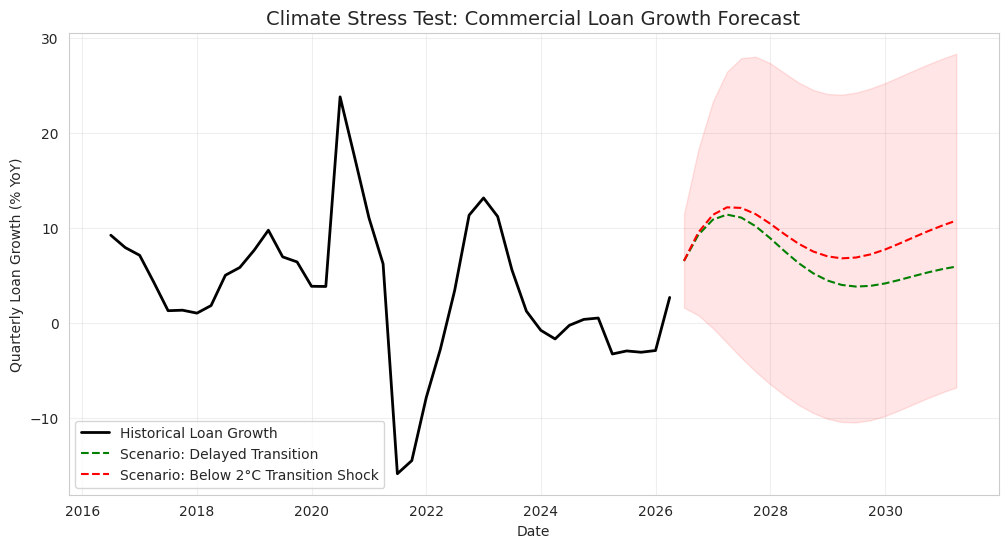

✅ Stress Test Analysis Complete.


In [125]:
# ---------------------------------------------------------
# Stress Test Forecast: C&I Loan Growth with Scenario Proxies
# ---------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# 1️⃣ Robust FRED Data Cleaning
# ---------------------------------------------------------
def clean_fred_data(file_path, value_col_name):
    try:
        df = pd.read_csv(file_path)
        # Dynamically find date column
        date_col = [c for c in df.columns if 'date' in c.lower()][0]
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
        # Force numeric, drop non-numeric
        df = df.apply(pd.to_numeric, errors='coerce')
        df = df.select_dtypes(include=[np.number])
        # Resample to quarter-end
        df_q = df.resample('QE').mean()
        if not df_q.empty:
            df_q.columns = [value_col_name]
        return df_q
    except Exception as e:
        print(f"⚠️ Error cleaning {file_path}: {e}")
        return pd.DataFrame()

# ---------------------------------------------------------
# 2️⃣ Load Historical FRED Data
# ---------------------------------------------------------
print("Loading Historical Data...")
df_loans = clean_fred_data('BUSLOANS.csv', 'Loans_Billions')
df_cpi = clean_fred_data('CPI.csv', 'CPI')
df_unemp = clean_fred_data('UNEMPLOYMENT.csv', 'Unemployment_Rate')

# Merge into master history
df_history = pd.concat([df_loans, df_cpi, df_unemp], axis=1).dropna()

# Feature Engineering: quarterly log-differences for stationarity
df_history['Loan_Growth'] = np.log(df_history['Loans_Billions']).diff(4) * 100
df_history['Inflation'] = np.log(df_history['CPI']).diff(4) * 100
df_history = df_history.dropna()

print(f"✅ Historical Data Loaded. Rows: {len(df_history)}")
print(df_history[['Loan_Growth', 'Unemployment_Rate']].head())

# ---------------------------------------------------------
# 3️⃣ Fit ARIMAX Model (Loan Growth ~ Unemployment)
# ---------------------------------------------------------
y_train = df_history['Loan_Growth']
X_train = df_history[['Unemployment_Rate']]

print("\nTraining ARIMAX Model...")
model = ARIMA(y_train, exog=X_train, order=(2, 0, 1))
model_fit = model.fit()
print(model_fit.summary())

# ---------------------------------------------------------
# 4️⃣ Generate NGFS Scenario Proxies
# ---------------------------------------------------------
forecast_steps = 20  # 5 years (20 quarters)
future_dates = pd.date_range(start=df_history.index[-1], periods=forecast_steps+1, freq='QE')[1:]

# Baseline: Delayed Transition Scenario (low stress)
X_future_delayed = pd.DataFrame(index=future_dates)
X_future_delayed['Unemployment_Rate'] = np.linspace(df_history['Unemployment_Rate'].iloc[-1], 
                                                    df_history['Unemployment_Rate'].iloc[-1]+0.5, 
                                                    forecast_steps)

# Stress Scenario: Below 2°C Transition Shock (high stress)
X_future_stress = pd.DataFrame(index=future_dates)
X_future_stress['Unemployment_Rate'] = np.linspace(df_history['Unemployment_Rate'].iloc[-1], 
                                                   df_history['Unemployment_Rate'].iloc[-1]+4.0, 
                                                   forecast_steps)

print("✅ Scenario Proxies Generated.")

# ---------------------------------------------------------
# 5️⃣ Forecast & Stress Test
# ---------------------------------------------------------
print("\nRunning Forecasts...")

# Forecast 1: Baseline
forecast_delayed = model_fit.get_forecast(steps=forecast_steps, exog=X_future_delayed)
pred_delayed = forecast_delayed.predicted_mean

# Forecast 2: Stress
forecast_stress = model_fit.get_forecast(steps=forecast_steps, exog=X_future_stress)
pred_stress = forecast_stress.predicted_mean
conf_int_stress = forecast_stress.conf_int()

# ---------------------------------------------------------
# 6️⃣ Plot Results
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

# Historical (last 10 years)
plt.plot(df_history.index[-40:], df_history['Loan_Growth'][-40:], label='Historical Loan Growth', color='black', linewidth=2)

# Baseline Scenario
plt.plot(pred_delayed.index, pred_delayed, label='Scenario: Delayed Transition', color='green', linestyle='--')

# Stress Scenario
plt.plot(pred_stress.index, pred_stress, label='Scenario: Below 2°C Transition Shock', color='red', linestyle='--')
plt.fill_between(pred_stress.index, conf_int_stress.iloc[:,0], conf_int_stress.iloc[:,1], color='red', alpha=0.1)

plt.title('Climate Stress Test: Commercial Loan Growth Forecast', fontsize=14)
plt.ylabel('Quarterly Loan Growth (% YoY)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("✅ Stress Test Analysis Complete.")

In [126]:
import sys
print(sys.executable)

/home/codespace/.python/current/bin/python


Loading Historical Data...
✅ Historical Data Loaded. Rows: 158
                  Chargeoff_Rate  Unemployment_Rate
observation_date                                   
1986-06-30                  1.47           7.166667
1986-09-30                  1.56           6.966667
1986-12-31                  1.48           6.833333
1987-03-31                  1.27           6.600000
1987-06-30                  1.20           6.266667

Training ARIMAX Model for Charge-Off Rate...
                               SARIMAX Results                                
Dep. Variable:         Chargeoff_Rate   No. Observations:                  158
Model:                 ARIMA(2, 0, 1)   Log Likelihood                  54.087
Date:                Mon, 02 Mar 2026   AIC                            -96.175
Time:                        15:39:33   BIC                            -77.799
Sample:                    06-30-1986   HQIC                           -88.712
                         - 09-30-2025                

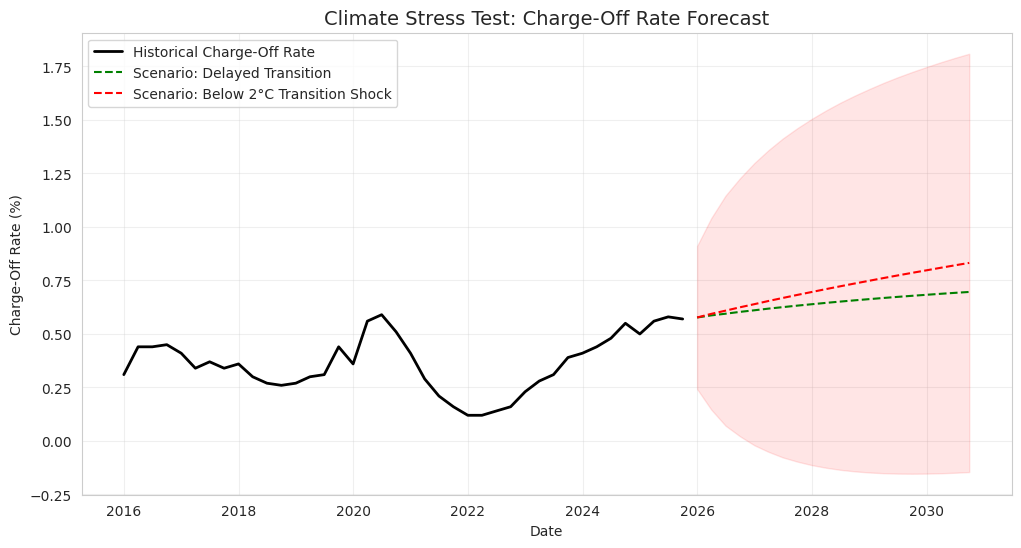

✅ Charge-Off Rate Stress Test Complete.


In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Suppress warnings for clean output
warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# 1️⃣ Clean FRED / historical data
# ---------------------------------------------------------
def clean_fred_data(file_path, value_col_name):
    try:
        df = pd.read_csv(file_path)
        date_col = [c for c in df.columns if 'date' in c.lower()][0]
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
        df_numeric = df.apply(pd.to_numeric, errors='coerce')
        df_q = df_numeric.resample('QE').mean()  # Quarterly
        if not df_q.empty:
            df_q.columns = [value_col_name]
        return df_q
    except Exception as e:
        print(f"⚠️ Error cleaning {file_path}: {e}")
        return pd.DataFrame()

# ---------------------------------------------------------
# 2️⃣ Load historical FRED data
# ---------------------------------------------------------
print("Loading Historical Data...")
df_loans = clean_fred_data('BUSLOANS.csv', 'Loans_Billions')
df_cpi = clean_fred_data('CPI.csv', 'CPI')
df_unemp = clean_fred_data('UNEMPLOYMENT.csv', 'Unemployment_Rate')
df_charge = clean_fred_data('CORBLACBS.csv', 'Chargeoff_Rate')
df_gdp = clean_fred_data('GDPC1.csv', 'GDP')

# Combine into master historical DataFrame
df_history = pd.concat([df_loans, df_cpi, df_unemp, df_charge, df_gdp], axis=1).dropna()

# Feature engineering
df_history['Loan_Growth'] = df_history['Loans_Billions'].pct_change(4) * 100
df_history['Inflation'] = df_history['CPI'].pct_change(4) * 100
df_history['GDP_Growth'] = df_history['GDP'].pct_change(4) * 100
df_history['Loan_Growth_Lag1'] = df_history['Loan_Growth'].shift(1)
df_history['Chargeoff_Lag1'] = df_history['Chargeoff_Rate'].shift(1)

# COVID dummy
covid_start = '2020-03-31'
covid_end = '2021-12-31'
df_history['COVID_Dummy'] = 0
df_history.loc[(df_history.index >= covid_start) & (df_history.index <= covid_end), 'COVID_Dummy'] = 1

# Drop NA rows after lags
df_history = df_history.dropna()

print(f"✅ Historical Data Loaded. Rows: {len(df_history)}")
print(df_history[['Chargeoff_Rate','Unemployment_Rate']].head())

# ---------------------------------------------------------
# 3️⃣ Fit ARIMAX Model: Charge-Off Rate ~ Unemployment
# ---------------------------------------------------------
y_charge = df_history['Chargeoff_Rate']
X_charge = df_history[['Unemployment_Rate']]

print("\nTraining ARIMAX Model for Charge-Off Rate...")
model_charge = ARIMA(y_charge, exog=X_charge, order=(2,0,1))
model_charge_fit = model_charge.fit()
print(model_charge_fit.summary())

# ---------------------------------------------------------
# 4️⃣ Generate NGFS Scenario Proxies (for stress testing)
# ---------------------------------------------------------
forecast_steps = 20  # 5 years
future_dates = pd.date_range(start=df_history.index[-1], periods=forecast_steps+1, freq='QE')[1:]

# Baseline: Delayed Transition Scenario (low stress)
X_future_delayed = pd.DataFrame(index=future_dates)
X_future_delayed['Unemployment_Rate'] = np.linspace(df_history['Unemployment_Rate'].iloc[-1],
                                                    df_history['Unemployment_Rate'].iloc[-1]+0.5,
                                                    forecast_steps)

# Stress Scenario: Below 2°C Transition Shock (high stress)
X_future_stress = pd.DataFrame(index=future_dates)
X_future_stress['Unemployment_Rate'] = np.linspace(df_history['Unemployment_Rate'].iloc[-1],
                                                   df_history['Unemployment_Rate'].iloc[-1]+4.0,
                                                   forecast_steps)

print("✅ Scenario Proxies Generated.")

# ---------------------------------------------------------
# 5️⃣ Forecast & Stress Test
# ---------------------------------------------------------
forecast_delayed = model_charge_fit.get_forecast(steps=forecast_steps, exog=X_future_delayed)
pred_delayed = forecast_delayed.predicted_mean

forecast_stress = model_charge_fit.get_forecast(steps=forecast_steps, exog=X_future_stress)
pred_stress = forecast_stress.predicted_mean
conf_int_stress = forecast_stress.conf_int()

# ---------------------------------------------------------
# 6️⃣ Plot Results
# ---------------------------------------------------------
plt.figure(figsize=(12,6))
plt.plot(df_history.index[-40:], df_history['Chargeoff_Rate'][-40:], label='Historical Charge-Off Rate', color='black', linewidth=2)
plt.plot(pred_delayed.index, pred_delayed, label='Scenario: Delayed Transition', color='green', linestyle='--')
plt.plot(pred_stress.index, pred_stress, label='Scenario: Below 2°C Transition Shock', color='red', linestyle='--')
plt.fill_between(pred_stress.index, conf_int_stress.iloc[:,0], conf_int_stress.iloc[:,1], color='red', alpha=0.1)
plt.title('Climate Stress Test: Charge-Off Rate Forecast', fontsize=14)
plt.ylabel('Charge-Off Rate (%)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("✅ Charge-Off Rate Stress Test Complete.")